In [5]:
!pip install numpy
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score


In [7]:
path="C:\\Users\\CANSU\\Desktop\\ML\\NASA TURBOFAN DATASET\\train_FD001.txt"
df=pd.read_csv(path,sep=" ")

In [8]:
df.head()


,1,1.1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8138.62,8.4195,0.03,392,2388,100.00,39.06,23.4190,Unnamed: 26,Unnamed: 27
0,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,NaN,NaN
1,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,NaN,NaN
2,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,NaN,NaN
3,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,NaN,NaN
4,1,6,-0.0043,-0.0001,100.0,518.67,642.10,1584.47,1398.37,14.62,...,8132.85,8.4108,0.03,391,2388,100.0,38.98,23.3669,NaN,NaN


In [9]:
df.shape

(20630, 28)

In [10]:
df.columns

Index(['1', '1.1', '-0.0007', '-0.0004', '100.0', '518.67', '641.82',
       '1589.70', '1400.60', '14.62', '21.61', '554.36', '2388.06', '9046.19',
       '1.30', '47.47', '521.66', '2388.02', '8138.62', '8.4195', '0.03',
       '392', '2388', '100.00', '39.06', '23.4190', 'Unnamed: 26',
       'Unnamed: 27'],
      dtype='str')

In [11]:
df.drop(['Unnamed: 27','Unnamed: 26'],axis=1,inplace=True) # I am dropping features that has just NaN value

In [12]:
df.columns

Index(['1', '1.1', '-0.0007', '-0.0004', '100.0', '518.67', '641.82',
       '1589.70', '1400.60', '14.62', '21.61', '554.36', '2388.06', '9046.19',
       '1.30', '47.47', '521.66', '2388.02', '8138.62', '8.4195', '0.03',
       '392', '2388', '100.00', '39.06', '23.4190'],
      dtype='str')

In [13]:
columns_name=["unit_number","time_in_cycles","os_1","os_2","os_3"]
for i in range(1,22):
    columns_name.append(f"s_{i}")
columns_name

['unit_number',
 'time_in_cycles',
 'os_1',
 'os_2',
 'os_3',
 's_1',
 's_2',
 's_3',
 's_4',
 's_5',
 's_6',
 's_7',
 's_8',
 's_9',
 's_10',
 's_11',
 's_12',
 's_13',
 's_14',
 's_15',
 's_16',
 's_17',
 's_18',
 's_19',
 's_20',
 's_21']

In [14]:
df.columns=columns_name
df.head()

,unit_number,time_in_cycles,os_1,os_2,os_3,s_1,s_2,s_3,s_4,s_5,...,s_12,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21
0,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
1,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
2,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
3,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044
4,1,6,-0.0043,-0.0001,100.0,518.67,642.10,1584.47,1398.37,14.62,...,521.68,2388.03,8132.85,8.4108,0.03,391,2388,100.0,38.98,23.3669


In [15]:
df.isna().sum()

unit_number       0
time_in_cycles    0
os_1              0
os_2              0
os_3              0
s_1               0
s_2               0
s_3               0
s_4               0
s_5               0
s_6               0
s_7               0
s_8               0
s_9               0
s_10              0
s_11              0
s_12              0
s_13              0
s_14              0
s_15              0
s_16              0
s_17              0
s_18              0
s_19              0
s_20              0
s_21              0
dtype: int64

In [16]:
for col in df.columns:
    print(df[col].value_counts())


unit_number
69    362
92    341
96    336
67    313
83    293
     ... 
58    147
57    137
70    137
91    135
39    128
Name: count, Length: 100, dtype: int64
time_in_cycles
2      100
3      100
4      100
5      100
6      100
      ... 
358      1
359      1
360      1
361      1
362      1
Name: count, Length: 362, dtype: int64
os_1
 0.0000    413
 0.0002    398
 0.0004    394
-0.0005    390
 0.0001    382
          ... 
-0.0075      1
 0.0087      1
-0.0087      1
-0.0078      1
 0.0077      1
Name: count, Length: 158, dtype: int64
os_2
-0.0003    2104
 0.0001    2097
 0.0000    2070
 0.0003    2065
-0.0004    2050
-0.0002    2049
 0.0002    2038
-0.0001    2029
 0.0004    1997
 0.0005    1068
-0.0005     958
 0.0006      71
-0.0006      34
Name: count, dtype: int64
os_3
100.0    20630
Name: count, dtype: int64
s_1
518.67    20630
Name: count, dtype: int64
s_2
642.50    190
642.56    189
642.53    188
642.60    184
642.67    179
         ... 
641.21      1
644.31      1
644.34  

In [17]:
df.drop(["os_3","s_1","s_5","s_10","s_16","s_18","s_19"],axis=1,inplace=True)#(Constant Features):These features have only one value.For this reason I dropped them. Because there aren't information gain for any ML models. Their variance is zero.

In [18]:
df.shape

(20630, 19)

In [19]:
corr_df=df.drop(["time_in_cycles","unit_number"],axis=1).corr()
corr_df

,os_1,os_2,s_2,s_3,s_4,s_6,s_7,s_8,s_9,s_11,s_12,s_13,s_14,s_15,s_17,s_20,s_21
os_1,1.000000,0.011640,0.009004,-0.005653,0.009530,-0.001338,-0.009420,-0.000435,-0.004292,0.011654,-0.001486,0.002302,-0.004474,0.007643,0.002587,-0.005692,-0.014541
os_2,0.011640,1.000000,0.007152,0.009059,0.014612,0.014365,-0.016605,0.013251,-0.005483,0.011673,-0.010901,0.018087,-0.006329,0.014117,0.012229,-0.010465,-0.007767
s_2,0.009004,0.007152,1.000000,0.602642,0.714938,0.132264,-0.702115,0.662334,0.273717,0.740052,-0.724605,0.661770,0.179743,0.675979,0.629875,-0.661805,-0.668022
s_3,-0.005653,0.009059,0.602642,1.000000,0.678421,0.116040,-0.664609,0.602481,0.322965,0.695900,-0.680307,0.600973,0.237136,0.639923,0.600021,-0.625961,-0.633915
s_4,0.009530,0.014612,0.714938,0.678421,1.000000,0.150490,-0.793120,0.746849,0.297401,0.830142,-0.815595,0.745147,0.190740,0.758454,0.703489,-0.748055,-0.745181
s_6,-0.001338,0.014365,0.132264,0.116040,0.150490,1.000000,-0.155733,0.152165,0.019354,0.160017,-0.155887,0.158288,-0.002110,0.149047,0.130817,-0.141434,-0.137432
s_7,-0.009420,-0.016605,-0.702115,-0.664609,-0.793120,-0.155733,1.000000,-0.767133,-0.217799,-0.822817,0.812721,-0.764598,-0.110042,-0.747048,-0.692882,0.736145,0.737430
s_8,-0.000435,0.013251,0.662334,0.602481,0.746849,0.152165,-0.767133,1.000000,-0.032114,0.782213,-0.786538,0.826086,-0.144795,0.700945,0.627779,-0.687031,-0.688838
s_9,-0.004292,-0.005483,0.273717,0.322965,0.297401,0.019354,-0.217799,-0.032114,1.000000,0.274585,-0.210229,-0.034808,0.963164,0.293736,0.337088,-0.285241,-0.292761
s_11,0.011654,0.011673,0.740052,0.695900,0.830142,0.160017,-0.822817,0.782213,0.274585,1.000000,-0.846883,0.780770,0.163405,0.780913,0.722298,-0.771528,-0.772567


In [20]:
#multicollinearity

for i in corr_df:
    for j in corr_df:
         if 0.85<corr_df[i][j]<1: #This means: %85 and more similar features.High Correlated
            print(i,j,corr_df[i][j]) # Sensor_9 and Sensor_14 indicate almost the same thing.
                                     # For this reason, I remove one of them



s_9 s_14 0.9631644152880176
s_14 s_9 0.9631644152880176


In [21]:
df.drop(["s_14"],axis=1,inplace=True)

<Axes: >

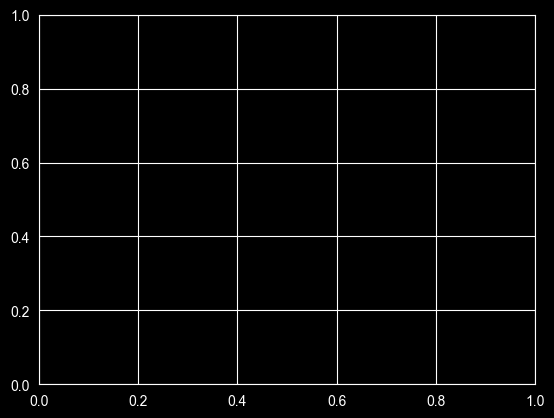

In [22]:
sns.barplot()

In [23]:
failure_cycles=df.groupby(by="unit_number").describe()["time_in_cycles"]["count"]#Failure cycles of the machines
failure_cycles.idxmax()

np.int64(69)

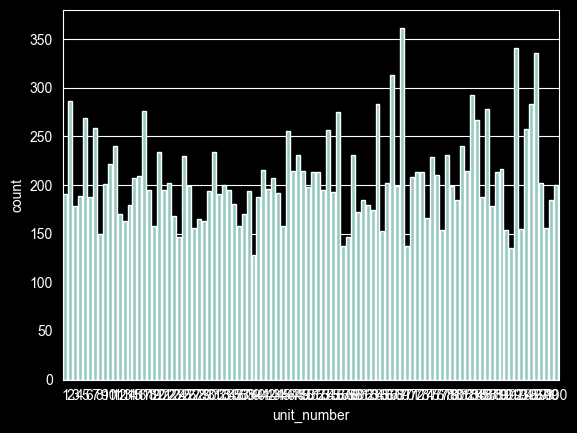

In [24]:
sns.barplot(failure_cycles)
plt.show()

In [25]:
failure_cycles.min()# this train data has minimum 128 cycles after broken machines.
failure_cycles.median()#This means that machines generally fail around 199 cycles.
failure_cycles.max()#This machines more durable than other machines


np.float64(362.0)

# Okay, let's continue with 3 machines to understand the data better.
* Machine 1 -> Machine to first failure, the has minimum cycle (128 cycle)
* Machine 2 -> This machine has an median cycle.(199 cycle)
* Machine 3 -> This machine, that actually we don't know its conditions, much quality machine from the dataset.(362 cycle)

In [26]:
failure_cycles

unit_number
1      191.0
2      287.0
3      179.0
4      189.0
5      269.0
       ...  
96     336.0
97     202.0
98     156.0
99     185.0
100    200.0
Name: count, Length: 100, dtype: float64

In [27]:
df["unit_number"].value_counts() #The value_counts() function in pandas returns a sorted object by default. So last element of this list is "durable machine".

unit_number
69    362
92    341
96    336
67    313
83    293
     ... 
58    147
57    137
70    137
91    135
39    128
Name: count, Length: 100, dtype: int64

In [28]:
machine_1_df=df.loc[df["unit_number"]==failure_cycles.idxmax()]
machine_1_df

,unit_number,time_in_cycles,os_1,os_2,s_2,s_3,s_4,s_6,s_7,s_8,s_9,s_11,s_12,s_13,s_15,s_17,s_20,s_21
13630,69,1,-0.0014,-0.0001,641.96,1587.10,1400.65,21.61,553.68,2388.00,9054.19,47.34,522.03,2388.03,8.4094,392,38.87,23.4081
13631,69,2,-0.0003,-0.0004,641.50,1594.24,1401.54,21.61,554.22,2388.04,9057.57,47.26,522.08,2388.08,8.4172,392,39.02,23.4189
13632,69,3,0.0006,-0.0003,642.73,1585.41,1405.22,21.61,554.11,2388.04,9052.77,47.35,522.05,2388.06,8.3869,392,38.82,23.3756
13633,69,4,-0.0001,-0.0003,642.00,1586.57,1408.44,21.61,553.84,2388.03,9061.89,47.35,521.63,2388.05,8.3890,391,38.99,23.2744
13634,69,5,0.0026,0.0002,642.37,1582.60,1403.07,21.61,554.00,2388.06,9064.65,47.34,522.31,2388.07,8.4042,392,38.87,23.3195
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13987,69,358,0.0040,-0.0002,643.74,1609.53,1428.26,21.61,551.60,2388.20,9053.75,48.28,520.31,2388.26,8.5460,397,38.53,23.0549
13988,69,359,0.0013,0.0003,643.46,1603.83,1429.82,21.61,551.62,2388.28,9056.81,48.13,519.86,2388.27,8.5116,396,38.28,23.0610
13989,69,360,0.0004,-0.0001,643.97,1597.75,1428.85,21.61,551.32,2388.31,9058.88,48.14,518.69,2388.26,8.5059,396,38.47,23.0422
13990,69,361,0.0016,-0.0002,643.65,1603.50,1433.95,21.61,551.13,2388.29,9055.52,48.09,520.48,2388.32,8.5270,396,38.52,23.1208


In [29]:
machine_2_df = df.loc[df["unit_number"]==failure_cycles.sort_values().index[50]]
machine_2_df

,unit_number,time_in_cycles,os_1,os_2,s_2,s_3,s_4,s_6,s_7,s_8,s_9,s_11,s_12,s_13,s_15,s_17,s_20,s_21
15753,79,1,-0.0048,-0.0005,642.22,1581.77,1392.78,21.61,554.44,2387.95,9055.37,47.10,522.54,2388.05,8.3795,391,39.02,23.5260
15754,79,2,0.0019,0.0001,641.97,1582.13,1399.23,21.61,554.88,2387.96,9052.66,47.15,522.39,2388.00,8.3828,391,39.06,23.3483
15755,79,3,0.0003,-0.0005,642.15,1584.59,1398.10,21.60,555.06,2387.99,9057.79,47.37,522.14,2387.99,8.4288,392,38.95,23.3914
15756,79,4,-0.0009,-0.0002,641.71,1584.17,1396.11,21.61,554.30,2387.99,9059.52,47.09,522.35,2388.00,8.3943,392,39.09,23.4778
15757,79,5,0.0023,0.0002,642.15,1582.11,1397.45,21.61,554.53,2388.04,9058.93,47.11,522.59,2388.06,8.4030,392,39.11,23.3996
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15947,79,195,-0.0010,-0.0004,643.84,1601.67,1429.44,21.61,551.55,2388.16,9097.21,48.12,520.30,2388.17,8.5201,395,38.54,23.0818
15948,79,196,-0.0019,0.0001,644.23,1597.47,1431.96,21.61,551.34,2388.18,9094.50,48.05,519.83,2388.21,8.5115,397,38.31,23.1359
15949,79,197,0.0005,0.0004,643.82,1603.82,1422.69,21.61,552.09,2388.18,9103.96,48.12,520.35,2388.22,8.5147,397,38.50,23.0924
15950,79,198,-0.0037,-0.0005,643.91,1606.34,1431.45,21.61,551.54,2388.23,9106.82,48.20,519.91,2388.18,8.5117,396,38.35,23.0653


In [30]:
machine_3_df = df.loc[df["unit_number"]==failure_cycles.idxmin()]
machine_3_df

,unit_number,time_in_cycles,os_1,os_2,s_2,s_3,s_4,s_6,s_7,s_8,s_9,s_11,s_12,s_13,s_15,s_17,s_20,s_21
7509,39,1,-0.0004,-0.0002,642.72,1592.37,1410.00,21.61,552.82,2388.12,9043.49,47.64,521.78,2388.10,8.4451,392,38.90,23.2947
7510,39,2,-0.0062,0.0002,642.61,1586.25,1407.99,21.61,553.25,2388.10,9049.07,47.60,521.56,2388.10,8.4279,395,38.82,23.4604
7511,39,3,0.0007,-0.0000,642.26,1586.25,1407.48,21.61,552.90,2388.13,9040.05,47.56,522.15,2388.07,8.4143,394,38.73,23.2669
7512,39,4,-0.0039,0.0005,642.46,1587.90,1405.23,21.61,553.55,2388.12,9053.54,47.40,521.83,2388.13,8.4599,394,38.82,23.3789
7513,39,5,0.0039,0.0002,642.31,1587.08,1408.78,21.61,553.40,2388.10,9044.92,47.50,521.76,2388.07,8.4607,394,38.73,23.3338
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7632,39,124,-0.0044,0.0005,643.40,1601.14,1426.38,21.61,551.69,2388.31,9035.42,48.10,519.56,2388.34,8.5038,396,38.52,23.0650
7633,39,125,0.0062,0.0002,643.82,1600.98,1436.58,21.61,549.85,2388.32,9048.84,48.34,520.04,2388.27,8.5306,397,38.54,23.2056
7634,39,126,0.0036,0.0002,644.24,1605.85,1426.13,21.61,551.74,2388.34,9031.64,48.01,519.66,2388.28,8.5338,396,38.45,23.1504
7635,39,127,0.0004,0.0001,644.53,1595.03,1426.95,21.61,551.59,2388.36,9037.13,48.27,519.24,2388.32,8.5383,395,38.29,23.1090


In [31]:
machine_2_df.describe().loc[["min","max","mean","std"]]

,unit_number,time_in_cycles,os_1,os_2,s_2,s_3,s_4,s_6,s_7,s_8,s_9,s_11,s_12,s_13,s_15,s_17,s_20,s_21
min,79.0,1.000000,-0.005500,-0.000600,641.270000,1576.180000,1387.560000,21.600000,551.000000,2387.950000,9044.980000,46.920000,519.620000,2387.940000,8.347700,390.000000,38.310000,23.030800
max,79.0,199.000000,0.005700,0.000400,644.230000,1606.340000,1436.930000,21.610000,555.700000,2388.260000,9106.820000,48.200000,523.030000,2388.220000,8.527300,397.000000,39.250000,23.551500
mean,79.0,100.000000,-0.000182,-0.000063,642.463317,1588.306181,1404.991960,21.609447,553.792764,2388.054422,9065.744623,47.403015,521.825628,2388.052864,8.423856,392.577889,38.894774,23.342871
std,0.0,57.590508,0.002126,0.000301,0.511563,6.771259,9.341945,0.002291,0.956728,0.059217,12.191204,0.290941,0.772041,0.064646,0.039313,1.596307,0.192524,0.119237


In [32]:
machine_1_df.describe().loc[["min","max","mean","std"]]

,unit_number,time_in_cycles,os_1,os_2,s_2,s_3,s_4,s_6,s_7,s_8,s_9,s_11,s_12,s_13,s_15,s_17,s_20,s_21
min,69.0,1.000000,-0.006800,-0.000500,641.500000,1579.660000,1393.380000,21.600000,550.340000,2387.990000,9045.070000,47.110000,518.690000,2387.980000,8.366800,389.000000,38.280000,22.963500
max,69.0,362.000000,0.007400,0.000500,644.190000,1609.530000,1433.950000,21.610000,555.410000,2388.310000,9073.870000,48.300000,522.660000,2388.330000,8.557200,397.000000,39.150000,23.521000
mean,69.0,181.500000,0.000009,0.000027,642.677099,1590.539862,1409.220304,21.609890,553.336243,2388.104917,9059.312265,47.548066,521.389779,2388.107707,8.441169,393.149171,38.809227,23.293400
std,0.0,104.644637,0.002255,0.000301,0.476280,5.391611,8.683928,0.001047,0.875482,0.068769,4.284010,0.250961,0.725743,0.067660,0.036559,1.458517,0.170118,0.103614


In [33]:
machine_3_df.describe().loc[["min","max","mean","std"]]

,unit_number,time_in_cycles,os_1,os_2,s_2,s_3,s_4,s_6,s_7,s_8,s_9,s_11,s_12,s_13,s_15,s_17,s_20,s_21
min,39.0,1.000000,-0.007300,-0.000400,641.850000,1580.980000,1398.770000,2.161000e+01,549.850000,2388.050000,9027.440000,47.350000,518.830000,2388.070000,8.396600,391.000000,38.290000,23.028100
max,39.0,128.000000,0.006400,0.000600,644.530000,1606.050000,1436.580000,2.161000e+01,554.090000,2388.360000,9054.620000,48.340000,522.150000,2388.340000,8.538300,397.000000,39.110000,23.462700
mean,39.0,64.500000,0.000167,0.000102,642.957969,1592.791250,1414.026172,2.161000e+01,552.838828,2388.163906,9043.124062,47.691406,520.953516,2388.167109,8.461070,393.679688,38.745938,23.242570
std,0.0,37.094474,0.002295,0.000288,0.457737,5.576874,7.647988,7.133347e-15,0.721779,0.064616,5.154605,0.218440,0.640344,0.060707,0.031873,1.229132,0.148803,0.088447


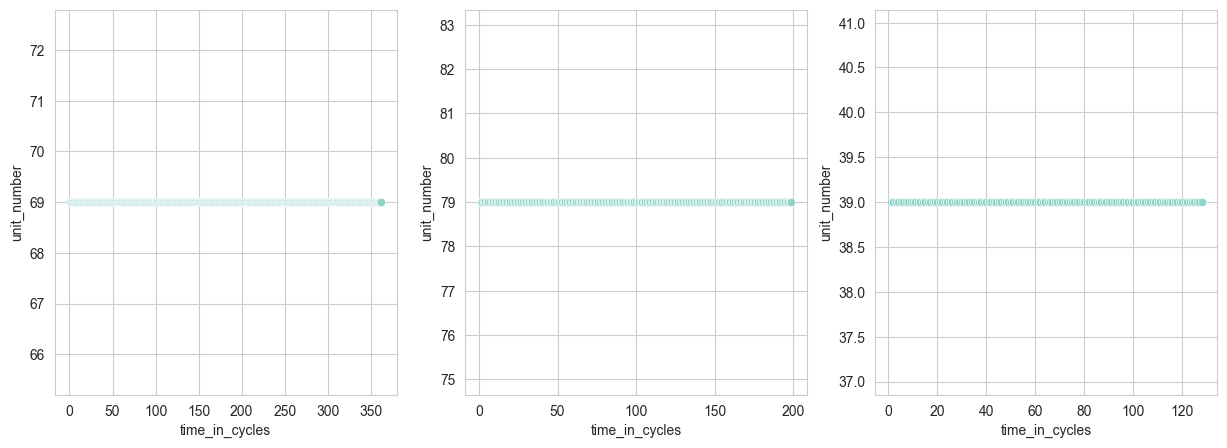

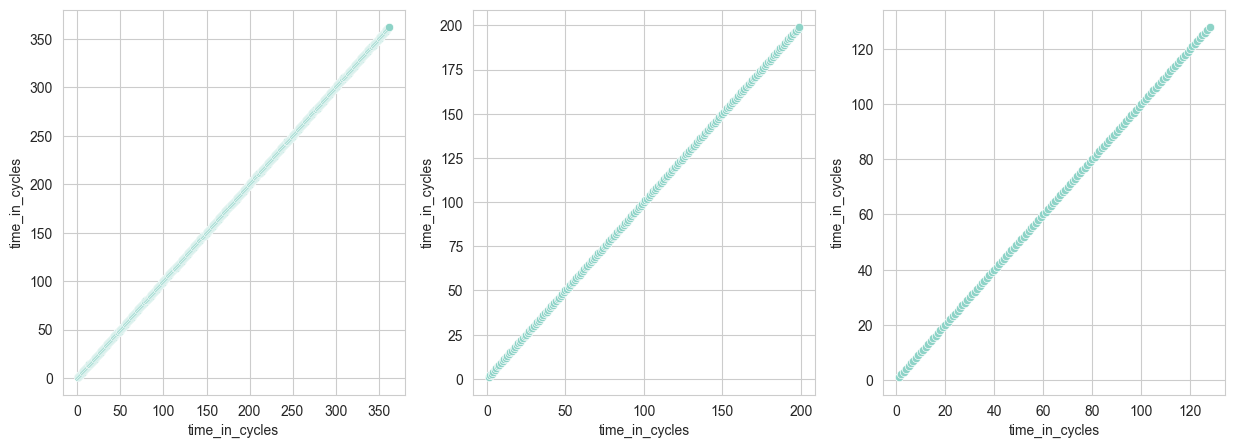

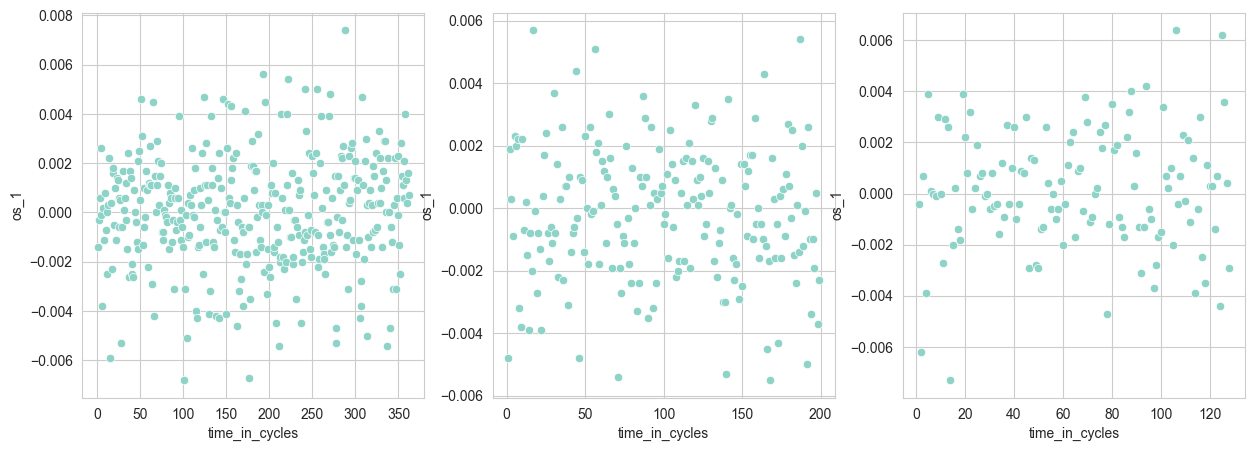

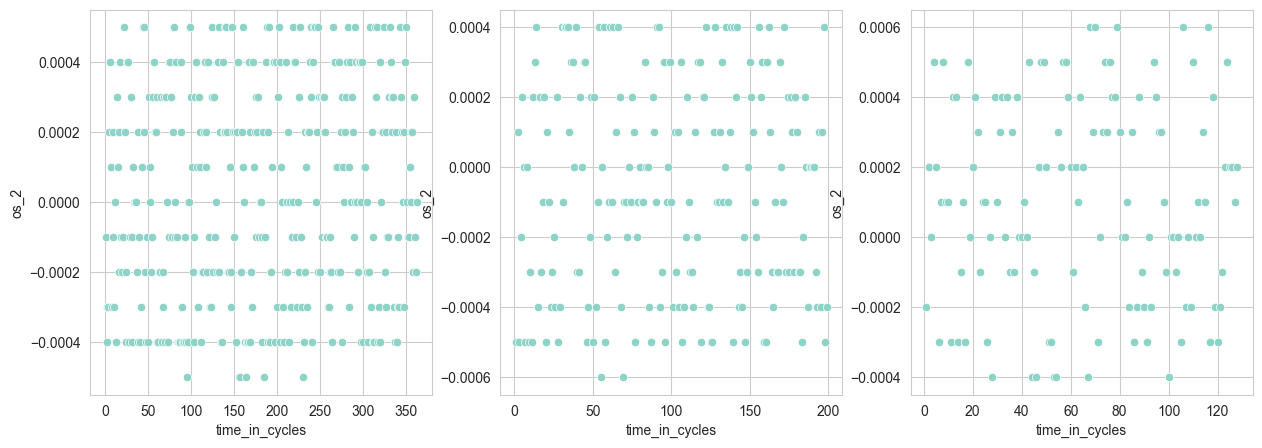

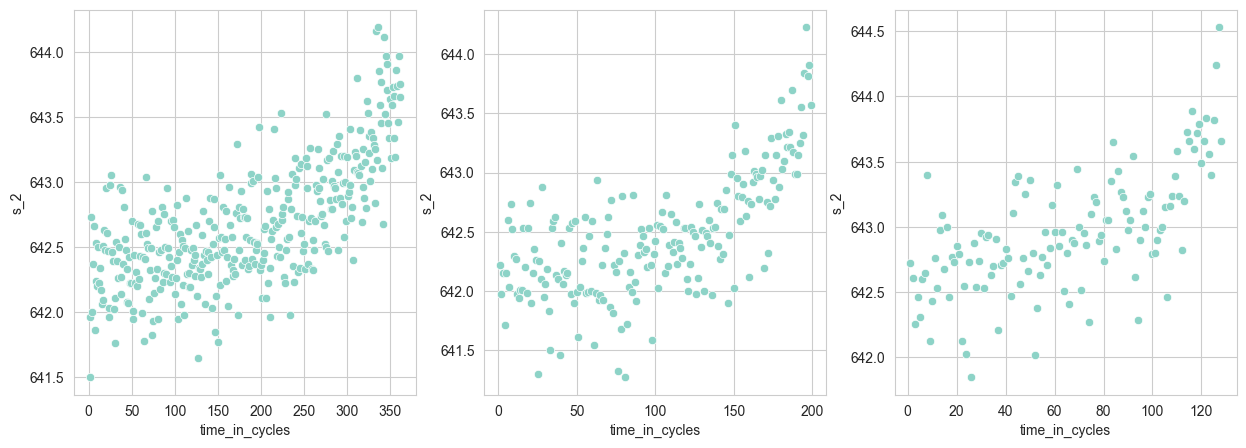

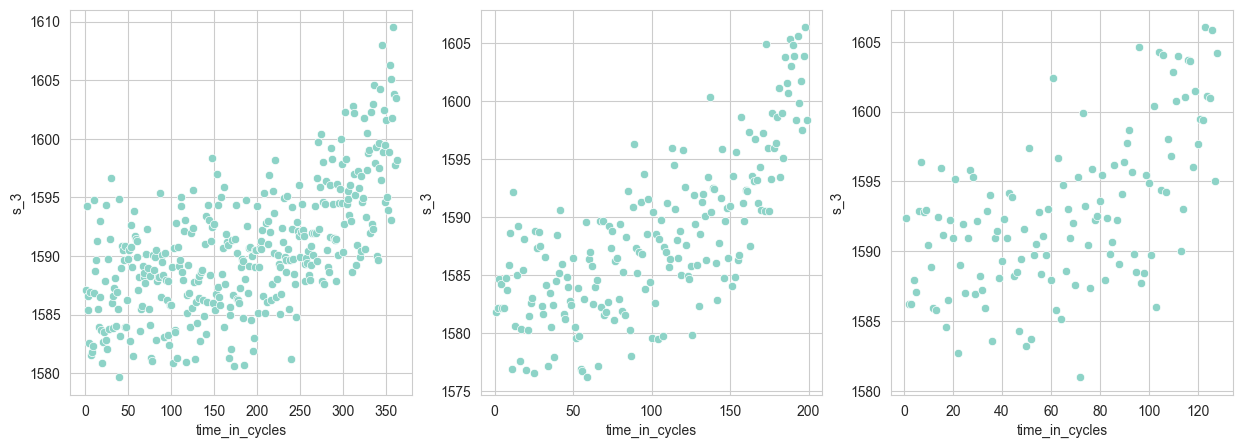

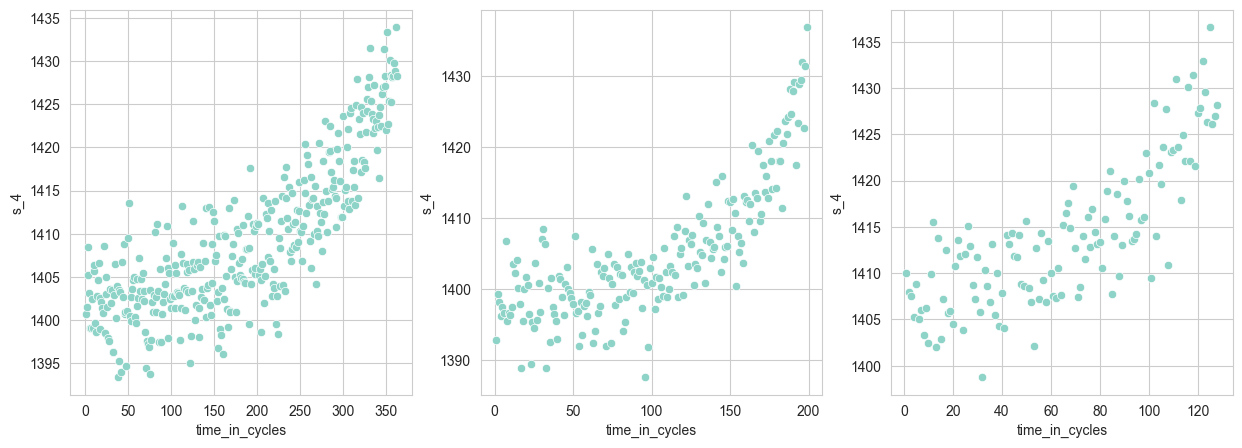

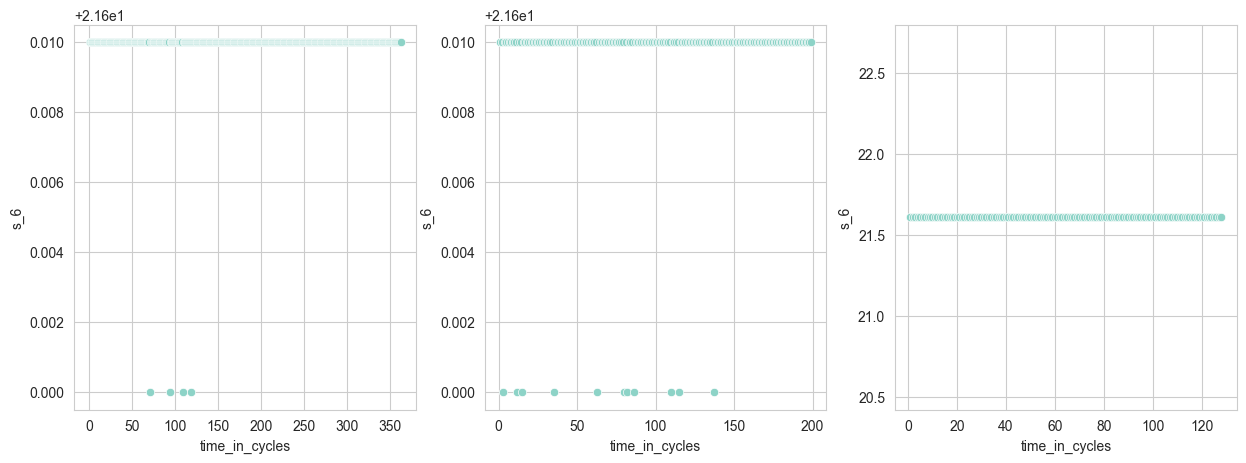

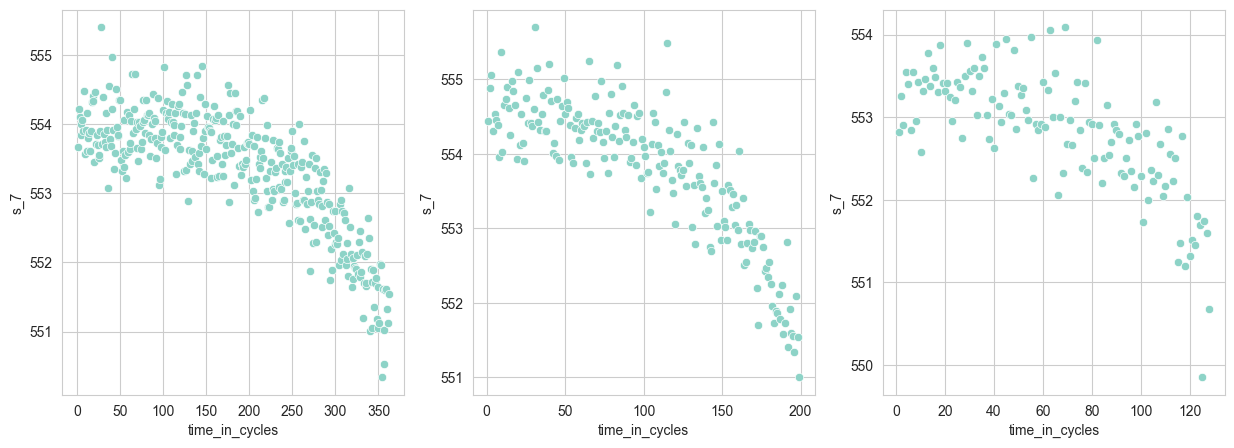

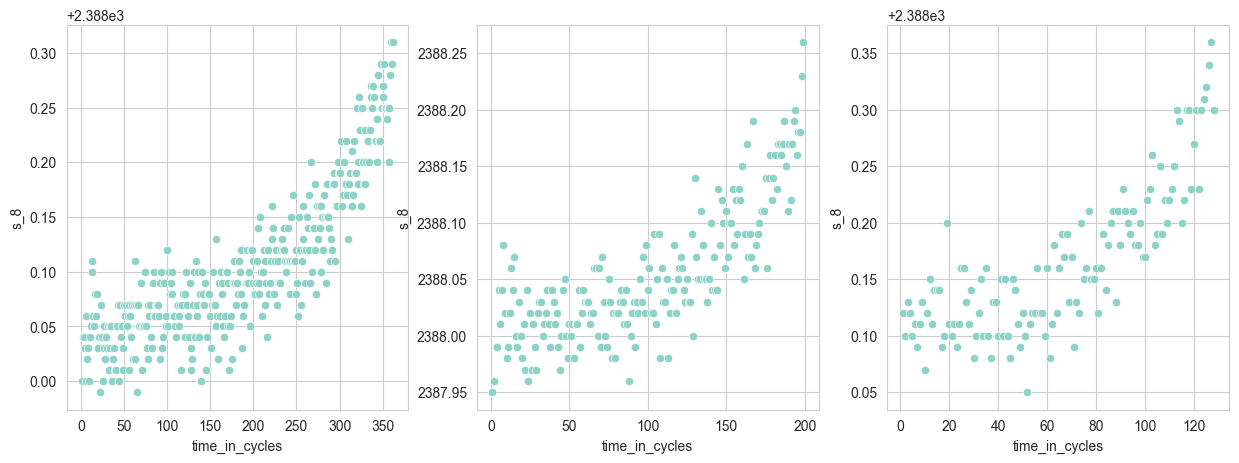

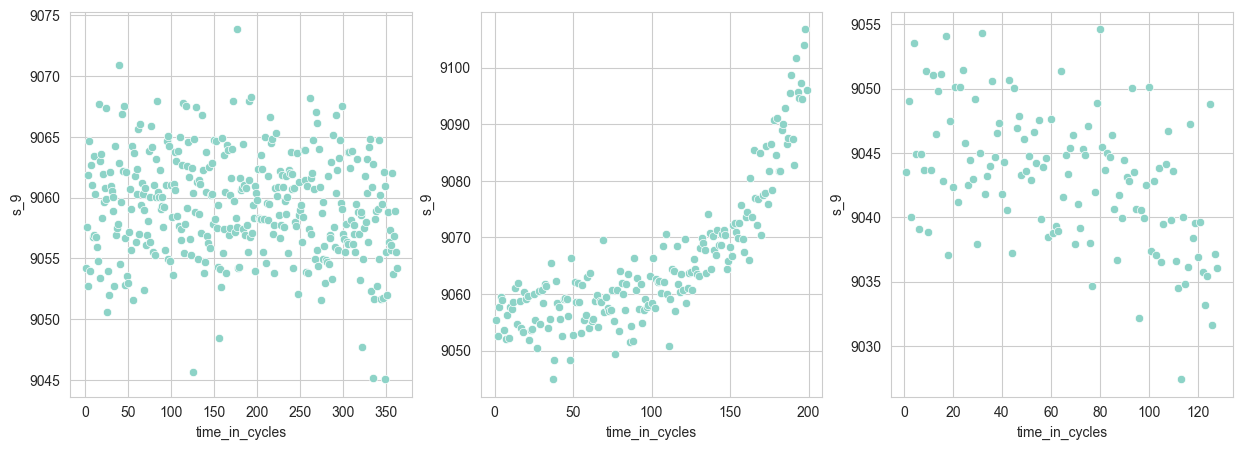

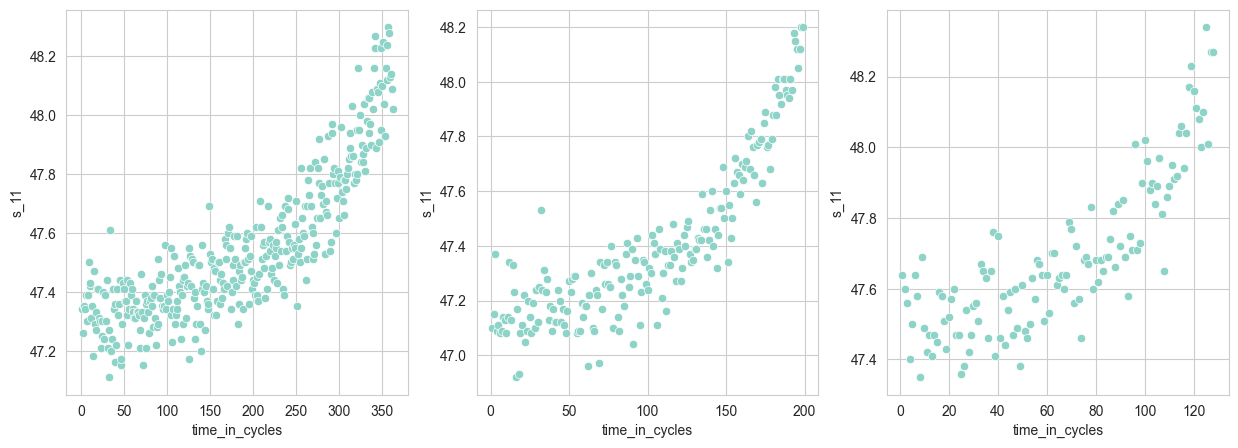

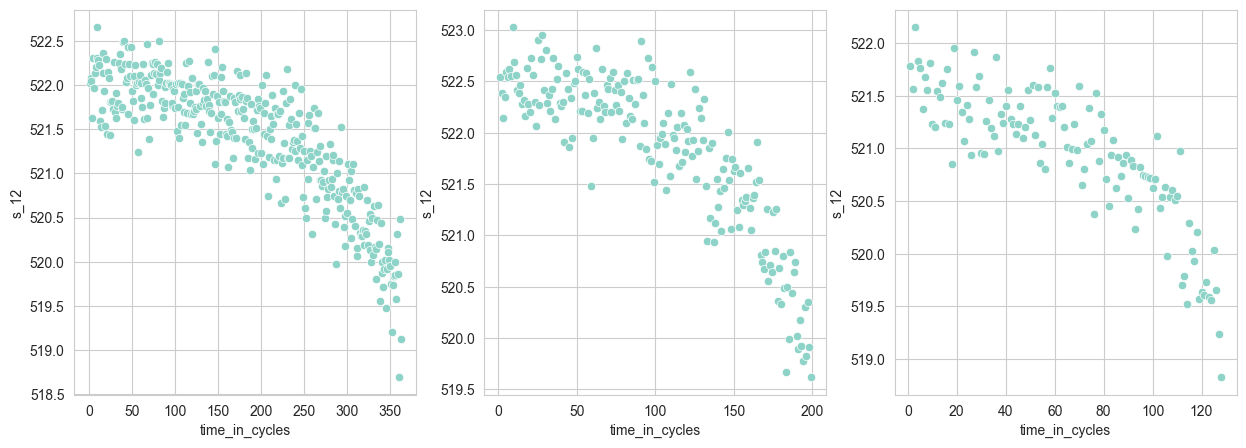

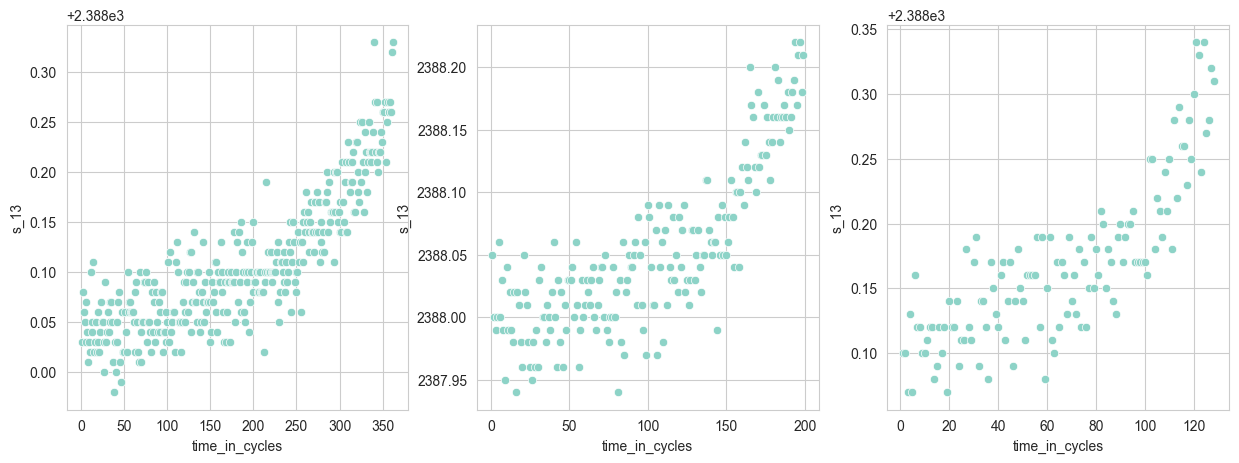

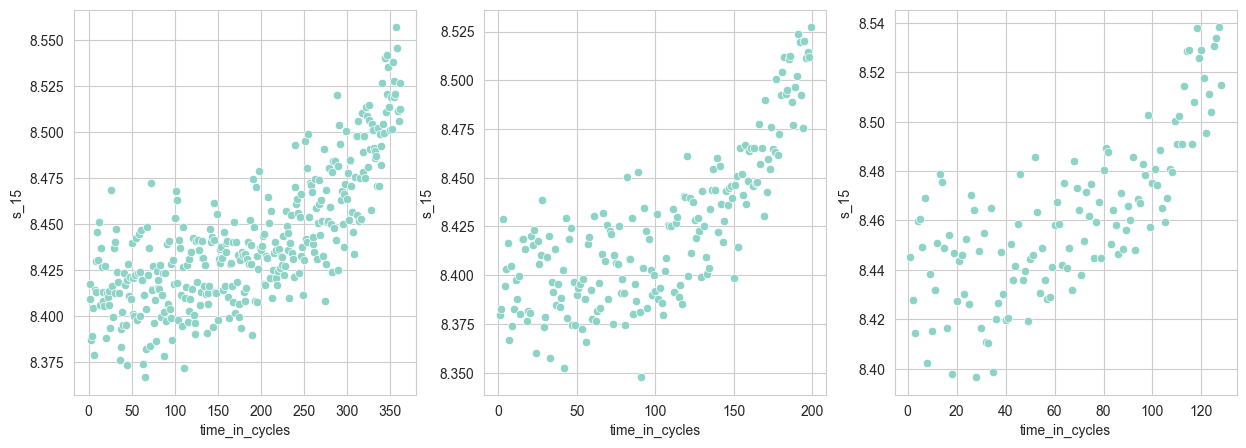

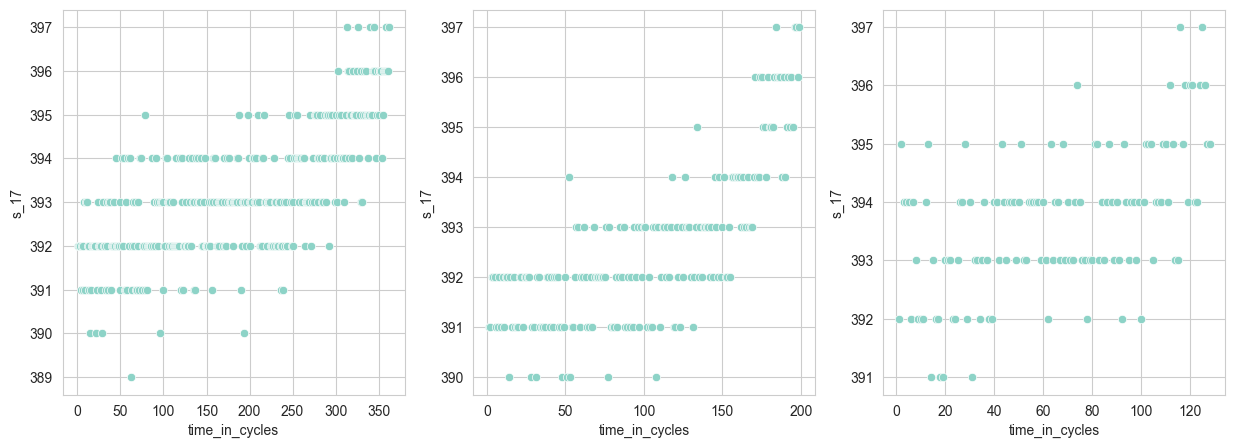

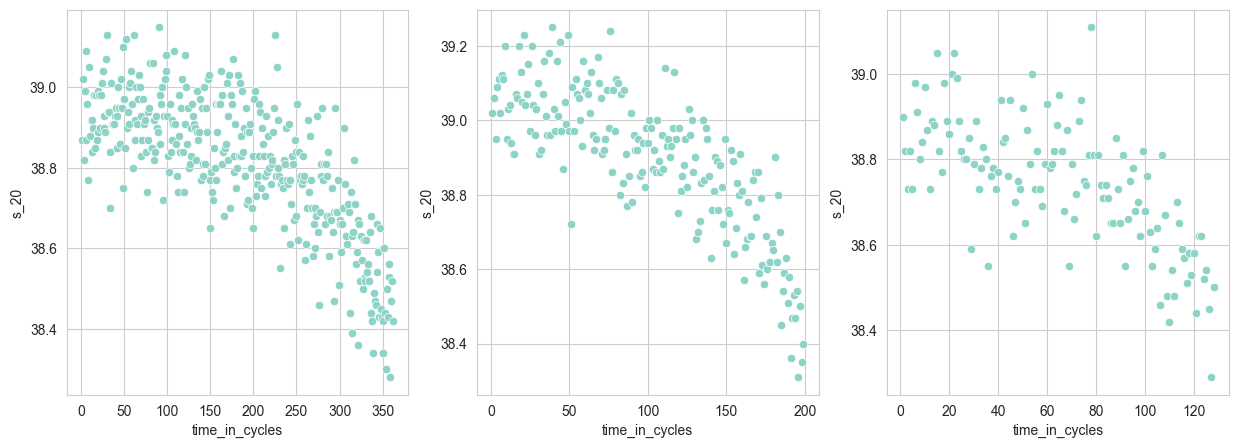

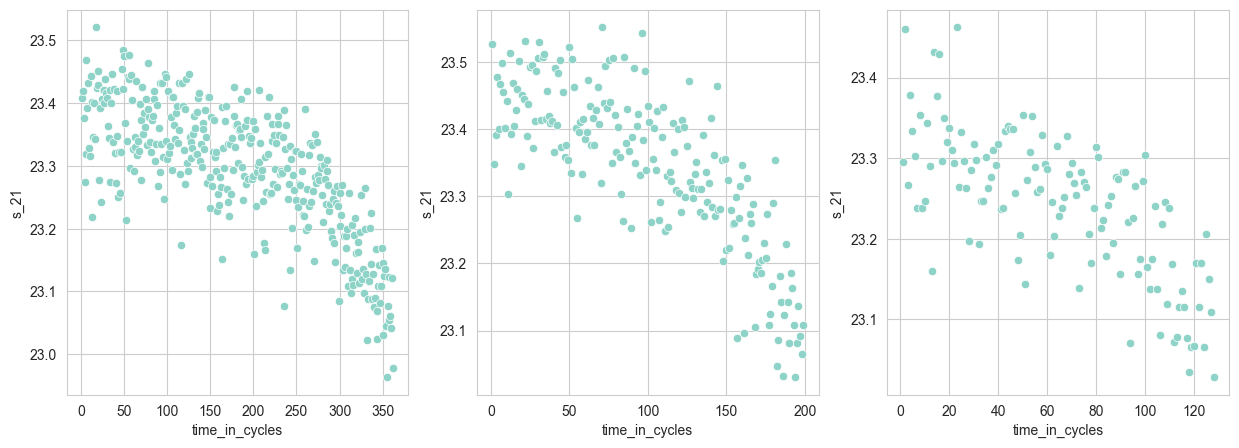

In [49]:

sns.set_style("whitegrid")

for i in range(len(machine_1_df.columns)):
    plt.figure(figsize=(15,5))

    plt.subplot(1,3,1)
    sns.scatterplot(x=machine_1_df["time_in_cycles"],y=machine_1_df.iloc[:,i])

    plt.subplot(1,3,2)
    sns.scatterplot(x=machine_2_df["time_in_cycles"],y=machine_2_df.iloc[:,i])

    plt.subplot(1,3,3)
    sns.scatterplot(x=machine_3_df["time_in_cycles"],y=machine_3_df.iloc[:,i])



In [ ]:
#I know, graphics dont make full sense without scaling all the data. Even though, we can see that sensor 7 and sensor 9 behave differently than other sensors